In [244]:
!pip install tf_keras # instala o pacote de compatibilidade

In [245]:
import cv2 # biblioteca de visão computacional
import numpy as np # biblioteca para cálculos com arrays e matrizes
from google.colab.patches import cv2_imshow # comando para mostrar imagens no colab
import zipfile # abre arquivos compactados
import tf_keras as keras # usa tf_keras para evitar conflito com o keras padrão
from tensorflow.keras.preprocessing.image import img_to_array # converte imagem em números

In [246]:
%tensorflow_version 2.x
import tensorflow
tensorflow.__version__ # mostra a versão instalada pra confirmar

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


'2.20.0'

In [247]:
from google.colab import drive # conecta o colab com o google drive
drive.mount('/content/gdrive') # autoriza o acesso às pastas do drive

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [243]:
path = "/content/gdrive/My Drive/Material.zip" # caminho do zip com os arquivos do modelo
zip_object = zipfile.ZipFile(file=path, mode="r") # abre o zip so para leitura
zip_object.extractall('./') # extrai tudo na pasta atual
zip_object.close() # fecha o zip para liberar memória

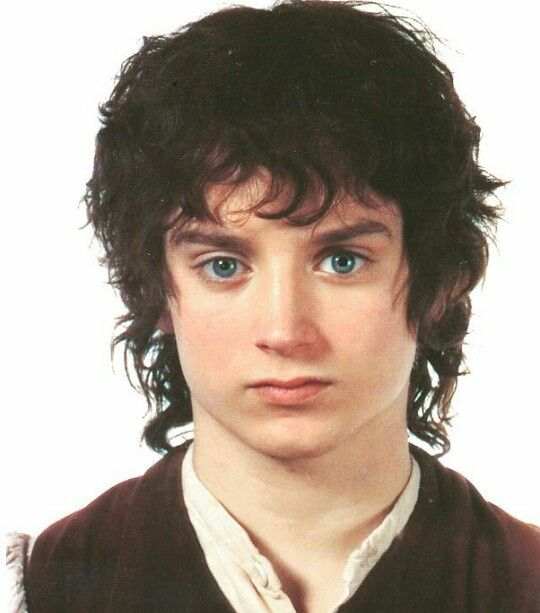

In [258]:
imagem = cv2.imread('/content/Frodo.jpeg') # carrega a imagem do drive
cv2_imshow(imagem) # mostra a imagem pra confirmar que carregou certo

In [249]:
cascade_faces = "Material/haarcascade_frontalface_default.xml" # arquivo com os padrões de rosto
caminho_modelo = "Material/modelo_01_expressoes.h5" # caminho do modelo de inteligência artificial

face_detection = cv2.CascadeClassifier(cascade_faces) # inicializa o detector de faces
classificador_emocoes = keras.models.load_model(caminho_modelo, compile=False) # carrega a rede neural treinada

# lista das 7 emoções que o modelo reconhece
expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]

In [250]:
original = imagem.copy() # copia a imagem para não alterar a original

cinza = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY) # converte para cinza

# detecta os rostos de jeito mais rigorosos pra evitar falsos positivos/
faces = face_detection.detectMultiScale(
    cinza,
    scaleFactor=1.1,
    minNeighbors=10,
    minSize=(60, 60)
)

print(f"Rostos encontrados: {len(faces)}") # mostra quantos rostos

Rostos encontrados: 1


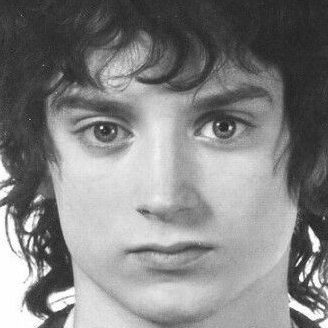

In [251]:
x, y, w, h = faces[0] # pega as coordenadas do primeiro rosto

roi = cinza[y:y + h, x:x + w] # recorta a região do rosto
cv2_imshow(roi) # mostra o rosto recortado em cinza

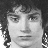

In [252]:
roi = cv2.resize(roi, (48, 48)) # redimensiona para 48x48 que é o tamanho que o modelo espera
cv2_imshow(roi) # mostra o recorte redimensionado

1/1 [==============================] - 0s 234ms/step


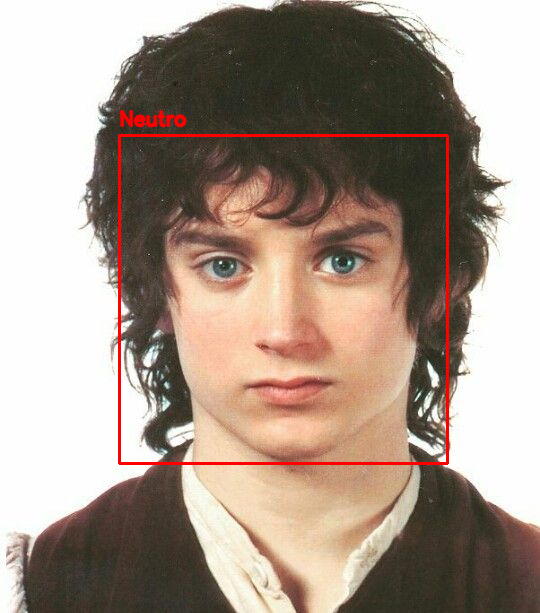

In [253]:
for (x, y, w, h) in faces:

    roi = cinza[y:y + h, x:x + w] # recorta a área do rosto encontrado
    roi = cv2.resize(roi, (48, 48)) # redimensiona para o padrão do modelo
    roi = roi.astype('float') / 255 # normaliza os pixels entre 0 e 1
    roi = img_to_array(roi) # converte para array que a IA consegue ler
    roi = np.expand_dims(roi, axis=0) # adiciona dimensão extra que o modelo exige

    preds = classificador_emocoes.predict(roi)[0] # roda a IA e pega as probabilidades

    if np.max(preds) > 0.50:
        label = expressoes[preds.argmax()] # pega o nome da emoção com maior probabilidade

        cv2.putText(original, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 255), 2, cv2.LINE_AA) # escreve a emoção em cima do quadrado
        cv2.rectangle(original, (x, y), (x + w, y + h), (0, 0, 255), 2) # desenha o quadrado vermelho

cv2_imshow(original) # mostra a imagem final com todos os rostos identificados

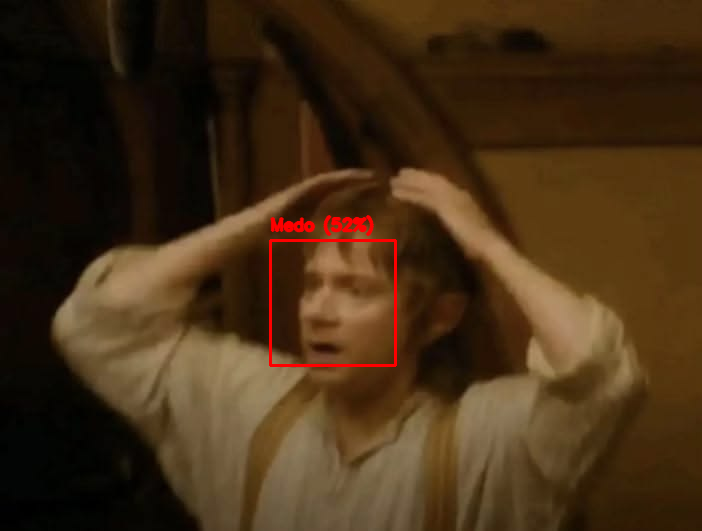

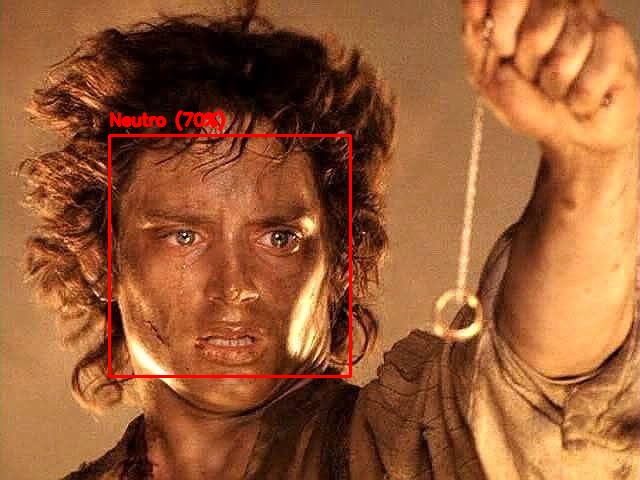

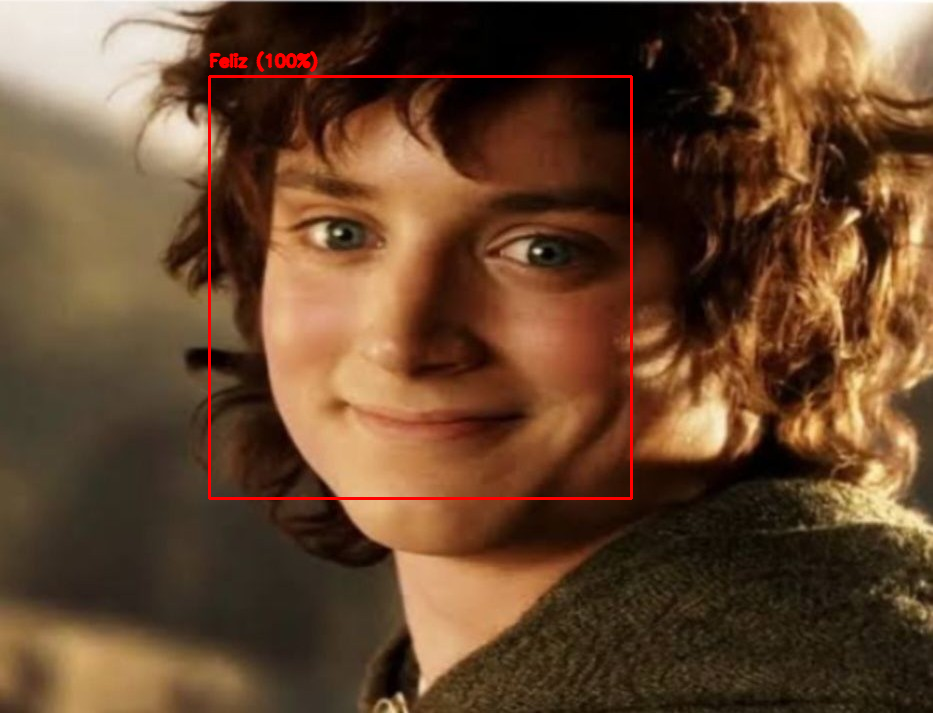

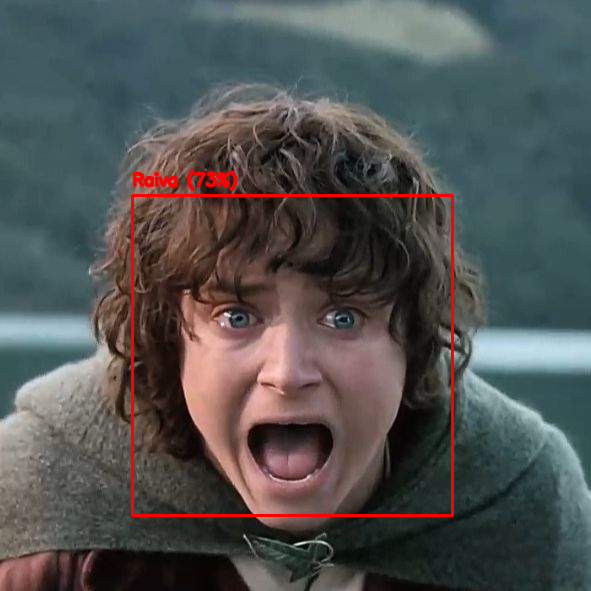

In [260]:
import os

pasta = '/content/Teste senhor doa aneis/'  # barra no final também resolve

arquivos = [f for f in os.listdir(pasta) if f.endswith(('.jpeg', '.jpg'))] # procurar pelas imagens

for arquivo in arquivos:

    caminho = os.path.join(pasta, arquivo)  # monta o caminho certinho
    img = cv2.imread(caminho)

    img_original = img.copy()
    cinza_loop = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)  # converte antes de detectar

    faces_encontradas = face_detection.detectMultiScale(
        cinza_loop,       # passa o cinza
        scaleFactor=1.1,
        minNeighbors=10,
        minSize=(60, 60)
    )
    for (fx, fy, fw, fh) in faces_encontradas:
        roi_loop = cinza_loop[fy:fy + fh, fx:fx + fw]
        roi_loop = cv2.resize(roi_loop, (48, 48))
        roi_loop = roi_loop.astype('float') / 255
        roi_loop = img_to_array(roi_loop)
        roi_loop = np.expand_dims(roi_loop, axis=0)

        preds_loop = classificador_emocoes.predict(roi_loop, verbose=0)[0]
        confianca = np.max(preds_loop)

        if confianca > 0.50:  # só mostra se tiver 50% ou mais
            label_loop = expressoes[preds_loop.argmax()]
            cv2.putText(img_original, f'{label_loop} ({confianca*100:.0f}%)', (fx, fy - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2, cv2.LINE_AA)
            cv2.rectangle(img_original, (fx, fy), (fx + fw, fy + fh), (0, 0, 255), 2)

    cv2_imshow(img_original)